In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [2]:
df0 = pd.read_csv(r"C:\Users\meet.gajera\OneDrive\Desktop\hcdr__\Data\row\previous_application.csv")

In [3]:
df = df0[['SK_ID_CURR','SK_ID_PREV', 'NAME_CONTRACT_STATUS']].copy()

In [4]:
df.sample(5)

,SK_ID_CURR,SK_ID_PREV,NAME_CONTRACT_STATUS
1238308,418543,1828467,Refused
277726,242699,2057063,Approved
1293185,121752,1013362,Approved
122935,312450,2797329,Approved
1036347,177496,1532733,Approved


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 3 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   SK_ID_CURR            1670214 non-null  int64 
 1   SK_ID_PREV            1670214 non-null  int64 
 2   NAME_CONTRACT_STATUS  1670214 non-null  object
dtypes: int64(2), object(1)
memory usage: 38.2+ MB


In [6]:
df.isnull().sum()

SK_ID_CURR              0
SK_ID_PREV              0
NAME_CONTRACT_STATUS    0
dtype: int64

In [7]:
# total previous application

total_app_count = df.groupby('SK_ID_CURR').agg(PREV_APP_COUNT=('SK_ID_PREV','count')).reset_index()

total_app_count.head()

,SK_ID_CURR,PREV_APP_COUNT
0,100001,1
1,100002,1
2,100003,3
3,100004,1
4,100005,2


In [8]:
total_app_count['PREV_APP_COUNT'].describe()

count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          77.000000
Name: PREV_APP_COUNT, dtype: float64

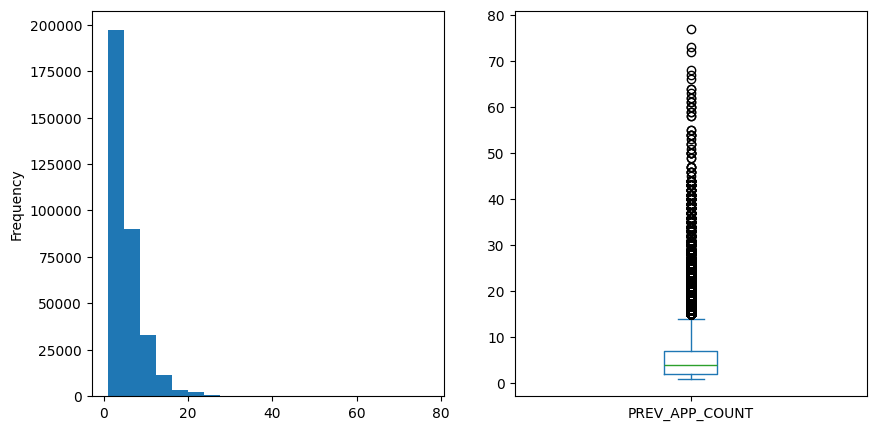

In [9]:
plt.figure(figsize=(10,5))
plt.subplot(121)
total_app_count['PREV_APP_COUNT'].plot(kind='hist', bins=20)
plt.subplot(122)
total_app_count['PREV_APP_COUNT'].plot(kind='box')
plt.show()

- The distribution is highly right-skewed, with most customers having only a few previous loan applications.
- A small number of customers have a large number of previous applications, resulting in several outliers.
- These outliers were retained because they represent genuine customer borrowing behavior rather than data entry errors.

In [10]:
# approval rate

df['APPROVED'] = (df['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)

total_app_rate = df.groupby('SK_ID_CURR').agg(APPROVAL_RATE=('APPROVED','mean')).reset_index()

In [11]:
total_app_rate.head()

,SK_ID_CURR,APPROVAL_RATE
0,100001,1.0
1,100002,1.0
2,100003,1.0
3,100004,1.0
4,100005,0.5


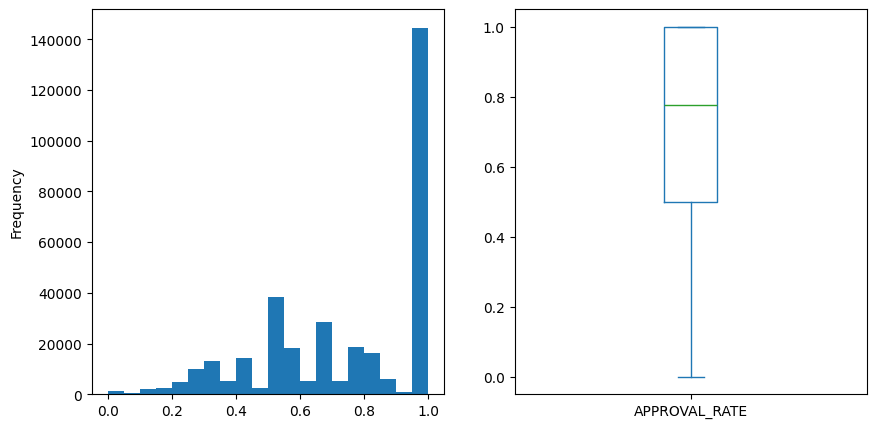

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(121)
total_app_rate['APPROVAL_RATE'].plot(kind='hist', bins=20)
plt.subplot(122)
total_app_rate['APPROVAL_RATE'].plot(kind='box')
plt.show()

- The approval rate represents the proportion of a customer's previous loan applications that were approved.
- Most customers have a high approval rate, with many having all previous applications approved (`APPROVAL_RATE = 1`).
- The median approval rate is approximately 0.77, indicating that at least half of the customers had over 77% of their previous applications approved.

In [17]:
prev_agg = df.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT = ('SK_ID_PREV','count'),
    APPROVAL_RATE = ('APPROVED','mean')
).reset_index()

In [18]:
prev_agg.head()

,SK_ID_CURR,PREV_APP_COUNT,APPROVAL_RATE
0,100001,1,1.0
1,100002,1,1.0
2,100003,3,1.0
3,100004,1,1.0
4,100005,2,0.5


In [19]:
prev_agg.to_csv(r'C:\Users\meet.gajera\OneDrive\Desktop\hcdr__\Data\featured\prev_app_featured.csv',index=False)